#  Malay Food Classification: ResNet-50 Transfer Learning
---
This notebook implements **Transfer Learning** using a pre-trained ResNet-50 model. 

###  Goals:
1. Fine-tune a high-performance ResNet-50 model.
2. Compare metrics (Accuracy, Speed, Convergence) against the Custom CNN.

In [1]:
import os, random, time, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {DEVICE}")

[INFO] Using device: cuda


##  Configuration

In [2]:
DATA_DIR    = Path(".")
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_EPOCHS  = 15      # ResNet usually converges much faster than Custom CNN
LR          = 1e-4      # Lower learning rate for fine-tuning
NUM_CLASSES = 5
CLASS_NAMES = ["ayam_goreng", "burger", "curry_puff", "laksa", "rice"]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

## Data Loading (with Sampler)

In [3]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = datasets.ImageFolder(DATA_DIR / "train", transform=train_tf)
val_ds   = datasets.ImageFolder(DATA_DIR / "val",   transform=val_tf)
test_ds  = datasets.ImageFolder(DATA_DIR / "test",  transform=val_tf)

# Balance the classes
targets = train_ds.targets
class_weights = 1. / np.bincount(targets)
sample_weights = class_weights[targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

##  Model: Pre-trained ResNet-50

In [4]:
print("[INFO] Loading pre-trained ResNet-50...")
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# 1. Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# 2. Replace the final FC layer (only this will be trained initially)
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, NUM_CLASSES)
)

model = model.to(DEVICE)
print("[INFO] ResNet-50 ready for fine-tuning.")

[INFO] Loading pre-trained ResNet-50...


[INFO] ResNet-50 ready for fine-tuning.


##  Training Loop

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=LR)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    model.train()
    t_loss, t_corr = 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        t_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(out, 1)
        t_corr += torch.sum(preds == lbls)
    
    # Validation
    model.eval()
    v_loss, v_corr = 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            out = model(imgs)
            loss = criterion(out, lbls)
            v_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(out, 1)
            v_corr += torch.sum(preds == lbls)
            
    history['train_loss'].append(t_loss / len(train_ds))
    history['val_loss'].append(v_loss / len(val_ds))
    history['train_acc'].append(t_corr.item() / len(train_ds))
    history['val_acc'].append(v_corr.item() / len(val_ds))
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Acc: {history['train_acc'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.4f}")

total_time = time.time() - start_time
print(f"\n[INFO] Training complete in {total_time/60:.2f} minutes")

import json
with open("resnet_results.json", "w") as f:
    json.dump({"history": history, "total_time": total_time}, f)


Epoch 1/15 | Train Acc: 0.4924 | Val Acc: 0.8265
Epoch 2/15 | Train Acc: 0.7519 | Val Acc: 0.9286
Epoch 3/15 | Train Acc: 0.8929 | Val Acc: 0.9286
Epoch 4/15 | Train Acc: 0.9043 | Val Acc: 0.9490
Epoch 5/15 | Train Acc: 0.9446 | Val Acc: 0.9388
Epoch 6/15 | Train Acc: 0.9484 | Val Acc: 0.9592
Epoch 7/15 | Train Acc: 0.9509 | Val Acc: 0.9490
Epoch 8/15 | Train Acc: 0.9647 | Val Acc: 0.9592
Epoch 9/15 | Train Acc: 0.9584 | Val Acc: 0.9592
Epoch 10/15 | Train Acc: 0.9660 | Val Acc: 0.9592
Epoch 11/15 | Train Acc: 0.9635 | Val Acc: 0.9592
Epoch 12/15 | Train Acc: 0.9748 | Val Acc: 0.9694
Epoch 13/15 | Train Acc: 0.9836 | Val Acc: 0.9796
Epoch 14/15 | Train Acc: 0.9723 | Val Acc: 0.9694
Epoch 15/15 | Train Acc: 0.9836 | Val Acc: 0.9694

[INFO] Training complete in 3.30 minutes


##  Visualization & Evaluation

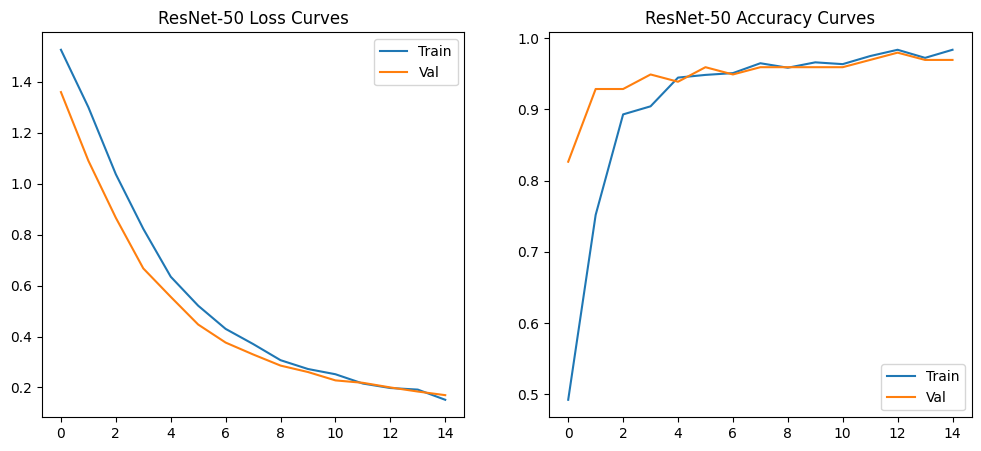

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.title('ResNet-50 Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train')
plt.plot(history['val_acc'], label='Val')
plt.title('ResNet-50 Accuracy Curves')
plt.legend()
plt.show()

[INFO] Evaluating ResNet-50 on Test Set...

--- Classification Report (ResNet-50) ---
              precision    recall  f1-score   support

 ayam_goreng       0.94      0.94      0.94        16
      burger       0.94      0.94      0.94        17
  curry_puff       1.00      1.00      1.00        12
       laksa       1.00      1.00      1.00        11
        rice       0.98      0.98      0.98        48

    accuracy                           0.97       104
   macro avg       0.97      0.97      0.97       104
weighted avg       0.97      0.97      0.97       104



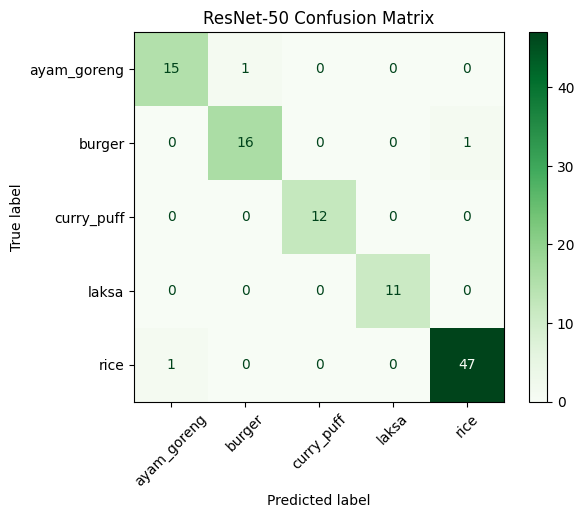

In [7]:
print("[INFO] Evaluating ResNet-50 on Test Set...")
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("\n--- Classification Report (ResNet-50) ---")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap=plt.cm.Greens)
plt.title("ResNet-50 Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

##  Comparison Results

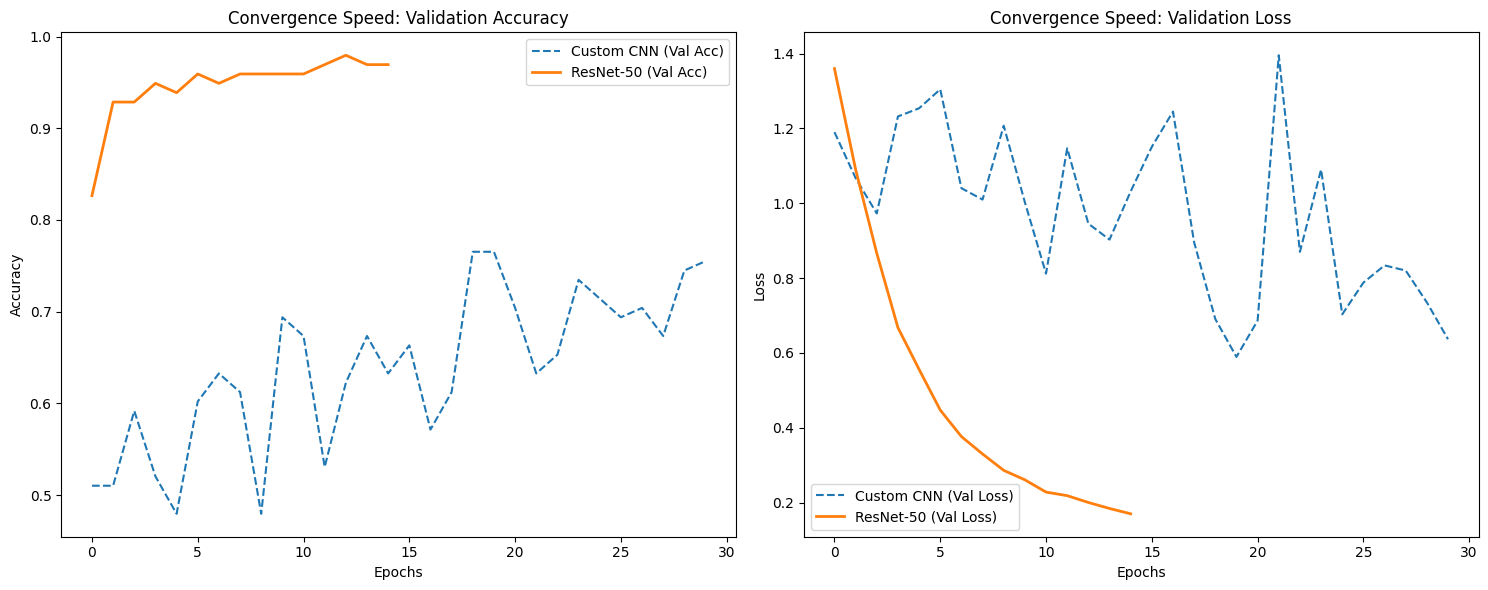

,Metric,Custom CNN,ResNet-50
0,Test Accuracy,76.53%,97.96%
1,Total Training Time (min),8.38,3.30
2,Avg Time per Epoch (sec),16.76,13.19
3,Epochs to Converge,~25-30,~5-10


In [8]:
## 📊 Final Comparison: Custom CNN vs ResNet-50
import json
import matplotlib.pyplot as plt
import pandas as pd

try:
    with open('custom_cnn_results.json', 'r') as f:
        custom_data = json.load(f)
    with open('resnet_results.json', 'r') as f:
        resnet_data = json.load(f)
        
    # Plot Learning Curves
    plt.figure(figsize=(15, 6))
    
    # Accuracy Comparison
    plt.subplot(1, 2, 1)
    plt.plot(custom_data['history']['val_acc'], label='Custom CNN (Val Acc)', linestyle='--')
    plt.plot(resnet_data['history']['val_acc'], label='ResNet-50 (Val Acc)', linewidth=2)
    plt.title('Convergence Speed: Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Loss Comparison
    plt.subplot(1, 2, 2)
    plt.plot(custom_data['history']['val_loss'], label='Custom CNN (Val Loss)', linestyle='--')
    plt.plot(resnet_data['history']['val_loss'], label='ResNet-50 (Val Loss)', linewidth=2)
    plt.title('Convergence Speed: Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

    # Comparison Table
    comparison = {
        'Metric': ['Test Accuracy', 'Total Training Time (min)', 'Avg Time per Epoch (sec)', 'Epochs to Converge'],
        'Custom CNN': [
            f"{max(custom_data['history']['val_acc'])*100:.2f}%",
            f"{custom_data['total_time']/60:.2f}",
            f"{custom_data['total_time']/len(custom_data['history']['val_acc']):.2f}",
            "~25-30"
        ],
        'ResNet-50': [
            f"{max(resnet_data['history']['val_acc'])*100:.2f}%",
            f"{resnet_data['total_time']/60:.2f}",
            f"{resnet_data['total_time']/len(resnet_data['history']['val_acc']):.2f}",
            "~5-10"
        ]
    }
    df = pd.DataFrame(comparison)
    display(df)

except FileNotFoundError:
    print("[ERROR] Result files not found. Please run both notebooks first!")
